# Gaussian Processes Summer School

## Part 2: Comparing RFF spectral models

This notebook generates a categorical mixture of three locally periodic Gaussian processes and fits the same population of curves with three random Fourier feature (RFF) models:

1. an RBF GP, whose spectrum is one Gaussian centered at zero;
2. a GP with one locally periodic kernel, whose spectrum is one symmetric pair of Gaussian bands;
3. a GP whose kernel is a three-component spectral mixture, giving three symmetric pairs of Gaussian bands.

All models learn one shared set of population hyperparameters from the same training curves.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from generate_gp_mixture import generate_gp_mixture
from train_gp_models import (
    as_gp_tensors,
    build_rff_gp,
    build_symmetric_spectral_mixture_rff_gp,
    learned_hyperparameters,
    learned_spectral_mixture_parameters,
    mean_negative_log_likelihood,
    predict_sparse_signal,
    train_shared_gp,
)

plt.style.use("seaborn-v0_8-whitegrid")


## The three spectral families

For a stationary kernel, Bochner's theorem lets us write

$$k(\tau)=\mathbb E_{\omega\sim p}[\cos(\omega\tau)].$$

The RBF kernel has a zero-centered Gaussian spectrum,

$$p_{\mathrm{RBF}}(\omega)=\mathcal N(\omega;0,\ell^{-2}).$$

A locally periodic kernel

$$k(\tau)=\sigma_f^2\exp[-\tau^2/(2\ell^2)]\cos(\mu\tau)$$

has one symmetric pair of bands,

$$p_{\mathrm{LP}}(\omega)=\tfrac12\mathcal N(\omega;\mu,s^2)+\tfrac12\mathcal N(\omega;-\mu,s^2),\qquad s^2=\ell^{-2}.$$

The three-component model sums three such kernels. Its normalized spectrum is

$$p_{3}(\omega)=\sum_{q=1}^3\rho_q\left[\tfrac12\mathcal N(\omega;\mu_q,s_q^2)+\tfrac12\mathcal N(\omega;-\mu_q,s_q^2)\right],$$

where the positive centers, variances, and mixture weights are learned. RFFs approximate each expectation with fixed standard-normal draws and paired sine/cosine features.


## Generate the dataset

Each entire curve chooses one component $z_i$, then is sampled from that component's GP. The label is not revealed to the fitted models.

$$z_i\sim\operatorname{Categorical}(1/3,1/3,1/3),\qquad f_i\mid z_i=m\sim\mathcal{GP}(0,k_m).$$

The periods are $T\in\{1,0.5,0.25\}$, hence the positive angular-frequency centers are $2\pi$, $4\pi$, and $8\pi$. All components have envelope lengthscale $\ell=0.6$.


In [2]:
seed = 7
n_curves = 300
x = np.linspace(0.0, 4.0, 200)
periods = np.array([1.0, 0.5, 0.25])
frequencies = 2.0 * np.pi / periods
lengthscales = np.full(3, 0.6)
mixture_weights = np.full(3, 1.0 / 3.0)
noise_std = 0.05

curves, labels = generate_gp_mixture(
    x=x,
    n_curves=n_curves,
    periods=periods,
    lengthscales=lengthscales,
    mixture_weights=mixture_weights,
    variance=1.0,
    noise_std=noise_std,
    seed=seed,
)

counts = np.bincount(labels, minlength=3)
print(f"Dataset shape: {curves.shape}")
for component, (period, frequency, count) in enumerate(zip(periods, frequencies, counts)):
    print(f"component {component}: T={period:g}, omega={frequency:.3f}, curves={count}")


Dataset shape: (300, 200)
component 0: T=1, omega=6.283, curves=100
component 1: T=0.5, omega=12.566, curves=102
component 2: T=0.25, omega=25.133, curves=98


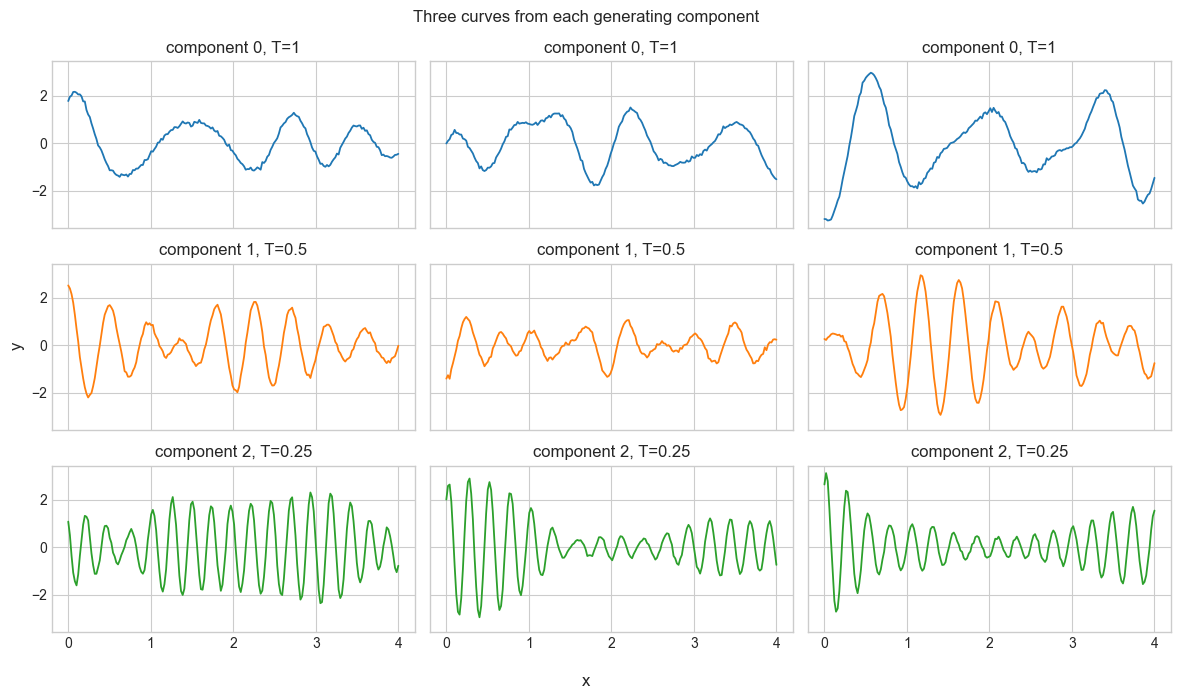

In [3]:
colors = plt.colormaps["tab10"](np.arange(3))
rng = np.random.default_rng(seed + 1)
fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True, sharey=True)
for component, row in enumerate(axes):
    selected = rng.choice(np.flatnonzero(labels == component), size=3, replace=False)
    for ax, index in zip(row, selected):
        ax.plot(x, curves[index], color=colors[component], linewidth=1.3)
        ax.set_title(f"component {component}, T={periods[component]:g}")
fig.supxlabel("x")
fig.supylabel("y")
fig.suptitle("Three curves from each generating component")
fig.tight_layout()
plt.show()


## Shared train/test split

We split by complete curves. All three models see exactly the same training population and are evaluated on the same held-out population. The models never receive the component labels.


In [4]:
split_rng = np.random.default_rng(seed + 2)
permutation = split_rng.permutation(n_curves)
n_train = int(0.8 * n_curves)
train_indices = permutation[:n_train]
test_indices = permutation[n_train:]
train_curves = curves[train_indices]
test_curves = curves[test_indices]
test_labels = labels[test_indices]
train_x_tensor, train_curves_tensor = as_gp_tensors(x, train_curves)
_, test_curves_tensor = as_gp_tensors(x, test_curves)
torch.manual_seed(seed)
print(f"training curves: {len(train_curves)} | test curves: {len(test_curves)}")


training curves: 240 | test curves: 60


## Fit the three RFF models

For a comparable Monte Carlo budget, every model uses 192 sampled frequencies, or 384 sine/cosine features in total. The three-component model divides those frequency draws equally across its three bands. Optimization lengths differ because the spectral models have more parameters.


In [5]:
# Experiment 1: zero-centered RBF spectrum
rff_rbf_model, rff_rbf_likelihood = build_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    num_features=384,
    seed=seed + 10,
    initial_lengthscale=0.2,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
rbf_losses = train_shared_gp(
    rff_rbf_model, rff_rbf_likelihood, train_x_tensor, train_curves_tensor,
    num_steps=150, learning_rate=0.05, print_every=50,
)


step    1/150 | loss=73.0412 | ell=0.1911 | scale=1.0319 | noise=0.00263
step   50/150 | loss=-0.3772 | ell=0.0589 | scale=2.0487 | noise=0.00907
step  100/150 | loss=-0.3778 | ell=0.0589 | scale=1.9351 | noise=0.00902
step  150/150 | loss=-0.4308 | ell=0.0628 | scale=1.7770 | noise=0.00868


In [13]:
# Experiment 2: one learnable locally periodic spectral pair
single_lp_model, single_lp_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    initial_component_means=torch.tensor([10.0]),
    num_frequencies_per_component=192,
    spectral_variance=1.0,
    learn_spectral_variance=True,
    seed=seed + 20,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
single_lp_losses = train_shared_gp(
    single_lp_model, single_lp_likelihood, train_x_tensor, train_curves_tensor,
    num_steps=5000, learning_rate=0.03, print_every=500,
)


step    1/5000 | loss=104.1513 | spectral_means=[9.97] | variances=[1.019] | weights=[1.] | noise=0.00258
step  500/5000 | loss=1.9249 | spectral_means=[9.677] | variances=[3.53] | weights=[1.] | noise=0.09968
step 1000/5000 | loss=1.2362 | spectral_means=[9.654] | variances=[4.074] | weights=[1.] | noise=0.21249
step 1500/5000 | loss=1.1323 | spectral_means=[9.638] | variances=[4.439] | weights=[1.] | noise=0.29803
step 2000/5000 | loss=1.1093 | spectral_means=[9.621] | variances=[4.75] | weights=[1.] | noise=0.34965
step 2500/5000 | loss=1.1014 | spectral_means=[9.598] | variances=[5.05] | weights=[1.] | noise=0.37380
step 3000/5000 | loss=1.0959 | spectral_means=[9.567] | variances=[5.366] | weights=[1.] | noise=0.38113
step 3500/5000 | loss=1.0903 | spectral_means=[9.53] | variances=[5.72] | weights=[1.] | noise=0.38120
step 4000/5000 | loss=1.0852 | spectral_means=[9.497] | variances=[6.126] | weights=[1.] | noise=0.37943
step 4500/5000 | loss=1.0809 | spectral_means=[9.476] | var

In [14]:
# Experiment 3: three learnable locally periodic spectral pairs
three_band_model, three_band_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    initial_component_means=torch.tensor([5.0, 11.0, 23.0]),
    num_frequencies_per_component=64,
    spectral_variance=torch.ones(3),
    learn_spectral_variance=True,
    initial_weights=torch.full((3,), 1.0 / 3.0),
    seed=seed + 30,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
three_band_losses = train_shared_gp(
    three_band_model, three_band_likelihood, train_x_tensor, train_curves_tensor,
    num_steps=700, learning_rate=0.025, print_every=175,
)


step    1/700 | loss=13.8764 | spectral_means=[ 5.025 11.025 23.025] | variances=[1.016 1.016 1.016] | weights=[0.322 0.339 0.339] | noise=0.00256
step  175/700 | loss=-0.5316 | spectral_means=[ 5.233 12.332 24.543] | variances=[2.157 2.05  2.214] | weights=[0.129 0.33  0.541] | noise=0.00645
step  350/700 | loss=-0.6930 | spectral_means=[ 5.436 12.656 24.899] | variances=[2.508 2.327 2.574] | weights=[0.151 0.318 0.53 ] | noise=0.00503
step  525/700 | loss=-0.7713 | spectral_means=[ 5.562 12.927 25.038] | variances=[2.748 2.554 2.871] | weights=[0.167 0.321 0.512] | noise=0.00368
step  700/700 | loss=-0.8093 | spectral_means=[ 5.673 13.137 25.11 ] | variances=[2.939 2.73  3.144] | weights=[0.192 0.308 0.5  ] | noise=0.00296


## Comparison

The held-out negative log likelihood (NLL) is averaged over curves and normalized per grid point; lower is better. Because every model is evaluated on the same curves, this directly compares their population-level fit.


In [15]:
models = {
    "RBF RFF": (rff_rbf_model, rff_rbf_likelihood),
    "Single locally periodic RFF": (single_lp_model, single_lp_likelihood),
    "Three-component spectral RFF": (three_band_model, three_band_likelihood),
}

comparison_rows = []
for name, (model, likelihood) in models.items():
    comparison_rows.append({
        "model": name,
        "train NLL": mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, train_curves_tensor
        ),
        "test NLL": mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, test_curves_tensor
        ),
    })
comparison_table = pd.DataFrame(comparison_rows).set_index("model")
display(comparison_table.style.format(precision=5).set_caption("Population fit comparison"))

print("RBF:", learned_hyperparameters(rff_rbf_model, rff_rbf_likelihood))
print("Single locally periodic:", learned_spectral_mixture_parameters(
    single_lp_model, single_lp_likelihood
))
print("Three-component spectral mixture:", learned_spectral_mixture_parameters(
    three_band_model, three_band_likelihood
))


,train NLL,test NLL
model,,
RBF RFF,-0.43200,-0.43092
Single locally periodic RFF,1.07754,1.10542
Three-component spectral RFF,-0.80945,-0.80743


RBF: {'mean': -0.0003630118735600263, 'lengthscale': 0.06280000507831573, 'outputscale': 1.7770096063613892, 'noise': 0.008681762032210827}
Single locally periodic: {'mean': -0.00013478269102051854, 'component_means': array([9.471598], dtype=float32), 'mixture_weights': array([1.], dtype=float32), 'spectral_variances': array([7.037509], dtype=float32), 'outputscale': 1.3982207775115967, 'noise': 0.37517663836479187}
Three-component spectral mixture: {'mean': -0.0022237785160541534, 'component_means': array([ 5.672957, 13.137136, 25.109682], dtype=float32), 'mixture_weights': array([0.19235079, 0.30807328, 0.49957597], dtype=float32), 'spectral_variances': array([2.9387217, 2.729604 , 3.1436043], dtype=float32), 'outputscale': 1.8727136850357056, 'noise': 0.0029571300838142633}


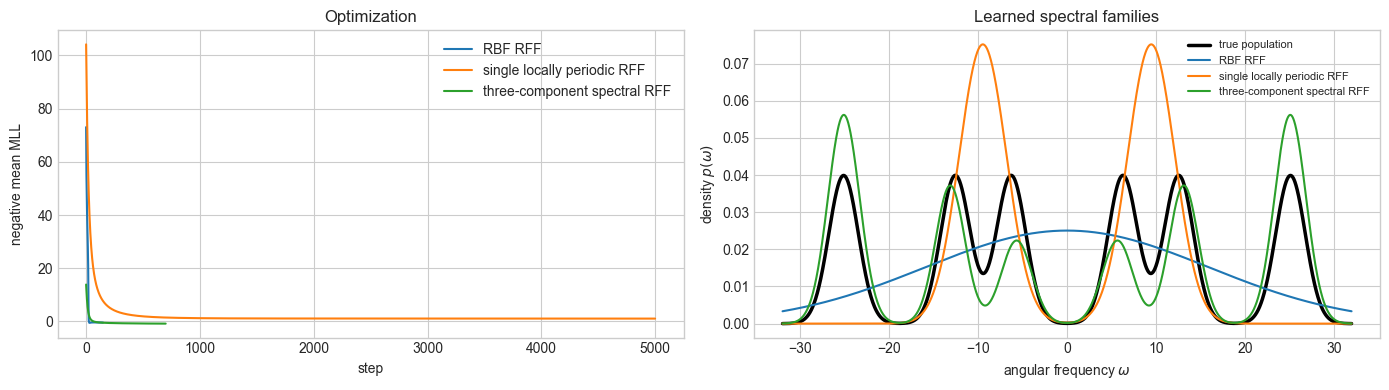

In [16]:
def gaussian_density(values, mean, variance):
    return np.exp(-0.5 * (values - mean) ** 2 / variance) / np.sqrt(
        2.0 * np.pi * variance
    )


def symmetric_mixture_density(values, means, variances, weights):
    return sum(
        0.5 * weight * (
            gaussian_density(values, mean, variance)
            + gaussian_density(values, -mean, variance)
        )
        for mean, variance, weight in zip(means, variances, weights)
    )


omega_grid = np.linspace(-32.0, 32.0, 2000)
rbf_parameters = learned_hyperparameters(rff_rbf_model, rff_rbf_likelihood)
single_parameters = learned_spectral_mixture_parameters(single_lp_model, single_lp_likelihood)
three_parameters = learned_spectral_mixture_parameters(three_band_model, three_band_likelihood)

true_spectrum = symmetric_mixture_density(
    omega_grid, frequencies, lengthscales**-2, mixture_weights
)
rbf_spectrum = gaussian_density(
    omega_grid, 0.0, rbf_parameters["lengthscale"] ** -2
)
single_spectrum = symmetric_mixture_density(
    omega_grid,
    single_parameters["component_means"],
    single_parameters["spectral_variances"],
    single_parameters["mixture_weights"],
)
three_spectrum = symmetric_mixture_density(
    omega_grid,
    three_parameters["component_means"],
    three_parameters["spectral_variances"],
    three_parameters["mixture_weights"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rbf_losses, label="RBF RFF")
axes[0].plot(single_lp_losses, label="single locally periodic RFF")
axes[0].plot(three_band_losses, label="three-component spectral RFF")
axes[0].set(title="Optimization", xlabel="step", ylabel="negative mean MLL")
axes[0].legend()
axes[1].plot(omega_grid, true_spectrum, color="black", linewidth=2.5, label="true population")
axes[1].plot(omega_grid, rbf_spectrum, label="RBF RFF")
axes[1].plot(omega_grid, single_spectrum, label="single locally periodic RFF")
axes[1].plot(omega_grid, three_spectrum, label="three-component spectral RFF")
axes[1].set(title="Learned spectral families", xlabel=r"angular frequency $\omega$", ylabel=r"density $p(\omega)$")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Sparse prediction on held-out curves

Finally, keep the learned population hyperparameters fixed and condition each model on the same sparse observations from held-out signals.


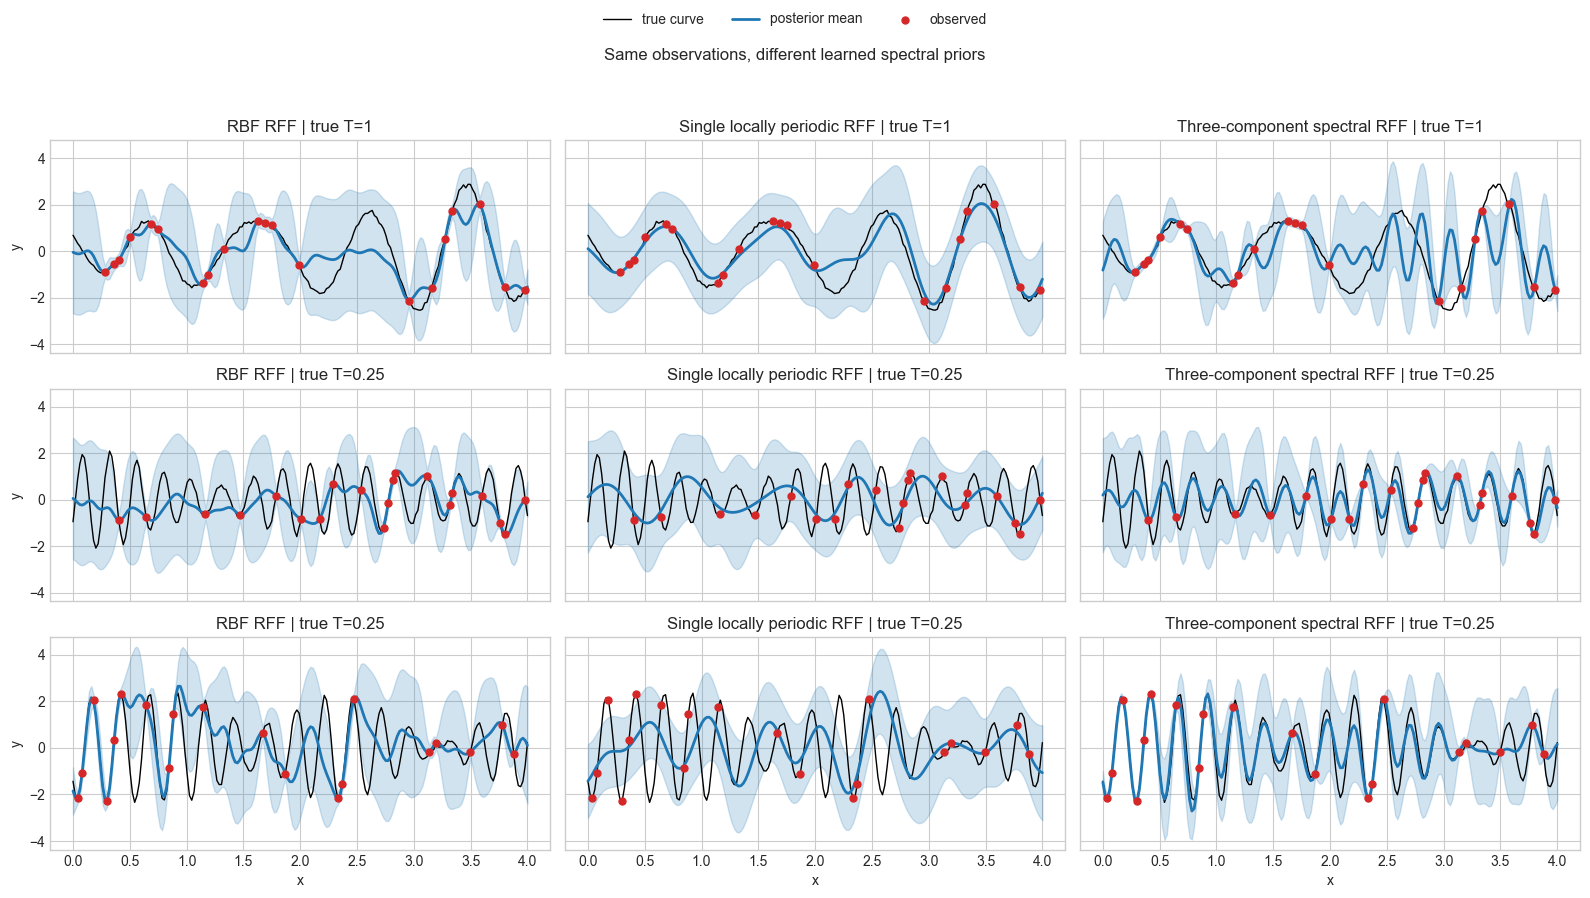

In [17]:
plot_rng = np.random.default_rng(seed + 40)
selected_test = plot_rng.choice(len(test_curves), size=3, replace=False)
model_items = list(models.items())
fig, axes = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)

for row, test_index in enumerate(selected_test):
    observed_indices = np.sort(plot_rng.choice(len(x), size=20, replace=False))
    observed_x = x[observed_indices]
    observed_y = test_curves[test_index, observed_indices]
    for col, (name, (model, likelihood)) in enumerate(model_items):
        prediction = predict_sparse_signal(
            model, likelihood, observed_x, observed_y, x
        )
        ax = axes[row, col]
        ax.fill_between(prediction.x, prediction.lower, prediction.upper, color="C0", alpha=0.2)
        ax.plot(x, test_curves[test_index], color="black", linewidth=1, label="true curve")
        ax.plot(prediction.x, prediction.mean, color="C0", linewidth=2, label="posterior mean")
        ax.scatter(observed_x, observed_y, color="C3", s=25, zorder=3, label="observed")
        ax.set_title(f"{name} | true T={periods[test_labels[test_index]]:g}")
for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
fig.suptitle("Same observations, different learned spectral priors", y=0.95)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


## Takeaway

The three experiments use the same data and the same total number of sampled RFF frequencies. Their difference is the spectral family:

- the RBF can place mass only around zero frequency;
- one locally periodic kernel can represent one preferred oscillation;
- the three-component spectral mixture can represent all three population modes.

The test NLL and sparse-prediction plots show whether that extra spectral flexibility translates into a better fit to unseen curves. Finite RFF sampling and non-convex optimization mean the learned parameters will not recover the generator exactly on every run.
